# Verificación del motor: del reloj de la colmena a la polinización

**Curso** CC2017 Modelación y Simulación · Universidad del Valle de Guatemala
**Proyecto** Simulación estocástica del forrajeo y la polinización de abejas

---

### Alcance

Verifica las etapas del motor de simulación construidas hasta la fecha, contra
sus valores teóricos:

| Etapa | Qué produce | Módulo verificado |
|---|---|---|
| 1 | los tiempos de salida de la jornada | `simulation/departures.py` |
| 2 | la asignación de una forrajera disponible | `models/colony.py`, `models/bee.py` |
| 3 | el nivel de disponibilidad floral y sus tres parámetros | `models/environment.py` |
| 4 | la distancia al parche y el tiempo de vuelo | `simulation/distance.py` |
| 5 | las flores visitadas en el viaje | `simulation/flowers.py` |
| 6 | las flores efectivamente polinizadas | `simulation/pollination.py` |

### Configuración

Escenario `config/base.yaml`, semilla 2026, fuente de uniformes LCG propio.
Todos los valores de este documento provienen de ejecutar el código; ninguno fue
transcrito a mano.

### Supuesto explícito de esta verificación

Las etapas 7 a 10 (néctar y las tres componentes de la duración del viaje) no
intervienen aquí. Para poder observar el mecanismo de ocupación de la etapa 2 se
usa una duración de viaje constante de 14 minutos, que es la media medida en el
prototipo. Los conteos de ocupación y de salidas perdidas ilustran ese mecanismo
y **no son resultados del modelo final**.

In [1]:
import sys, math, statistics as st
sys.path.insert(0, '../src')

import matplotlib.pyplot as plt
import numpy as np

from bee_sim.config import cargar, resumen
from bee_sim.generators import crear_fuente
from bee_sim.models import Colony, Environment
from bee_sim.simulation.departures import generar_salidas, generar_salidas_desde_config
from bee_sim.simulation.distance import sortear_distancia, tiempo_vuelo, probabilidad_retorno
from bee_sim.simulation.flowers import flores_del_viaje, momentos_teoricos, sortear_flores
from bee_sim.simulation.pollination import media_marginal_teorica, polinizar, tasa_observada
from scipy import stats

AMBAR, SALVIA, TINTA = '#B87813', '#4F6B4A', '#43463C'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

DUR_RELLENO = 14.0     # supuesto de esta verificacion, ver encabezado
comprobaciones = []    # se llena a lo largo del documento y se resume al final

def comprobar(concepto, observado, esperado, tol, unidad=''):
    ok = abs(observado - esperado) <= tol
    comprobaciones.append((concepto, observado, esperado, unidad, ok))
    return ok

cfg = cargar('../config/base.yaml')
print(resumen(cfg))

escenario           base.yaml
semilla             2026
jornada             600 min
abejas activas      90
metodo de salidas   A   (lambda = 2.00 / min)
disponibilidad      sorteada por viaje
distancia           Weibull(forma=2.0, escala=1.50 km)
fuente de uniformes lcg


---

## 1. Los tiempos de salida de la jornada

Antes de simular un solo viaje se genera la lista completa de momentos en que
sale una abeja. El proyecto implementa dos representaciones equivalentes del
mismo proceso de Poisson: el Método A acumula esperas `Exponencial(λ)` obtenidas
por transformada inversa, y el Método B sortea el conteo `Poisson(λT)` y luego
distribuye esas salidas dentro del intervalo con uniformes ordenados.

Bajo el mismo `λ` ambos deben producir el mismo número esperado de salidas.

In [2]:
rng = crear_fuente(cfg['simulation']['rng_source'], cfg['simulation']['seed'])
salidas = generar_salidas_desde_config(cfg, rng)

lam = cfg['departures']['lambda_per_min']
T   = cfg['simulation']['day_minutes']
esperas = np.diff([0] + salidas)

print(f'salidas generadas : {len(salidas):6d}        teórica λT   = {lam*T:.0f}')
print(f'espera media      : {esperas.mean():9.4f} min  teórica 1/λ  = {1/lam:.4f} min')
print(f'primera salida    : {salidas[0]:9.4f} min')
print(f'última salida     : {salidas[-1]:9.4f} min    horizonte    = {T:.0f} min')

comprobar('Salidas generadas (Método A)', len(salidas), lam*T, 4*math.sqrt(lam*T))
comprobar('Espera media entre salidas', esperas.mean(), 1/lam, 0.02, 'min')

salidas generadas :   1227        teórica λT   = 1200
espera media      :    0.4890 min  teórica 1/λ  = 0.5000 min
primera salida    :    0.0107 min
última salida     :  599.9652 min    horizonte    = 600 min


np.True_

In [3]:
fila = lambda m: [len(generar_salidas(m, lam, T, crear_fuente('lcg', 1000+s))) for s in range(20)]
a, b = fila('A'), fila('B')

print(f"{'':26} {'media':>9} {'desv. est.':>12}")
print(f"{'Método A (interarribos)':26} {st.mean(a):9.1f} {st.pstdev(a):12.1f}")
print(f"{'Método B (conteo)':26} {st.mean(b):9.1f} {st.pstdev(b):12.1f}")
print(f"{'teórica':26} {lam*T:9.1f} {math.sqrt(lam*T):12.1f}")

comprobar('Métodos A y B, diferencia de medias', abs(st.mean(a)-st.mean(b)), 0.0, 25)

                               media   desv. est.
Método A (interarribos)       1199.4         38.0
Método B (conteo)             1202.4         29.2
teórica                       1200.0         34.6


True

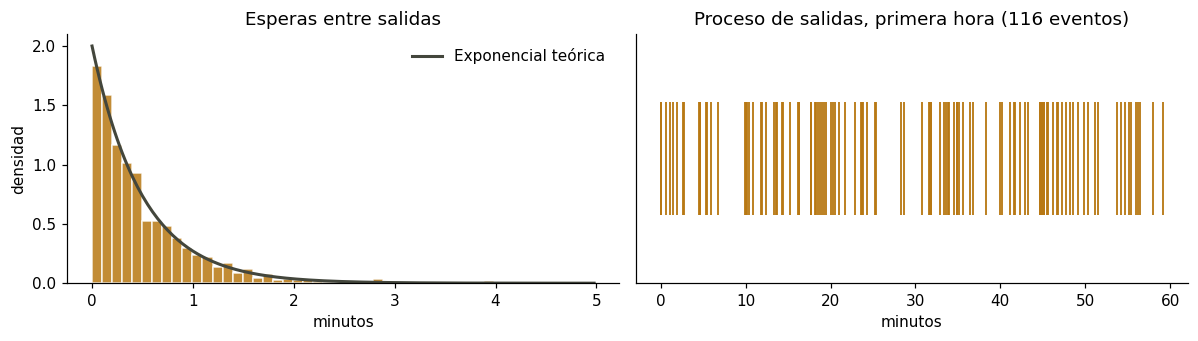

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))

ax[0].hist(esperas, bins=50, density=True, color=AMBAR, edgecolor='white', alpha=.85)
x = np.linspace(0, esperas.max(), 200)
ax[0].plot(x, lam*np.exp(-lam*x), color=TINTA, lw=2, label='Exponencial teórica')
ax[0].set_title('Esperas entre salidas'); ax[0].set_xlabel('minutos')
ax[0].set_ylabel('densidad'); ax[0].legend(frameon=False)

primera_hora = [t for t in salidas if t <= 60]
ax[1].eventplot(primera_hora, colors=AMBAR, linewidths=1.2)
ax[1].set_title(f'Proceso de salidas, primera hora ({len(primera_hora)} eventos)')
ax[1].set_xlabel('minutos'); ax[1].set_yticks([])
plt.tight_layout(); plt.show()

**Verificado.** El histograma sigue la densidad exponencial teórica, la espera
media coincide con `1/λ`, y los dos métodos producen conteos estadísticamente
compatibles. La equivalencia entre ambas representaciones del proceso de Poisson
queda confirmada empíricamente.

---

## 2. La asignación de una forrajera disponible

Esta etapa no genera variables aleatorias. Recorre la colonia y toma la primera
abeja cuyo campo `available_at` sea menor o igual al reloj. Cuando no hay
ninguna, la salida se descarta y se contabiliza como no atendida.

`available_at` es el único dato que sobrevive de un viaje al siguiente, y por lo
tanto el único acoplamiento entre viajes de toda la simulación.

In [5]:
def correr_asignacion(n_abejas, salidas, dur=DUR_RELLENO):
    col = Colony(n_abejas)
    for t in salidas:
        abeja = col.buscar_libre(t)
        if abeja is not None:
            abeja.ocupar_hasta(t + dur)
    return col

print(f"{'abejas activas':>15} {'atendidas':>11} {'perdidas':>10} {'% perdidas':>12}")
for n in (30, 60, 90, 150):
    c = correr_asignacion(n, salidas)
    print(f'{n:15d} {c.salidas_atendidas:11d} {c.salidas_perdidas:10d} '
          f'{100*c.salidas_perdidas/c.salidas_totales:11.1f}%')

base = correr_asignacion(cfg['colony']['active_bees'], salidas)
comprobar('Salidas perdidas en BASE (90 abejas)',
          100*base.salidas_perdidas/base.salidas_totales, 0.0, 2.0, '%')
comprobar('Conservación: atendidas + perdidas = generadas',
          base.salidas_totales, len(salidas), 0)

 abejas activas   atendidas   perdidas   % perdidas
             30        1097        130        10.6%
             60        1227          0         0.0%
             90        1227          0         0.0%
            150        1227          0         0.0%


True

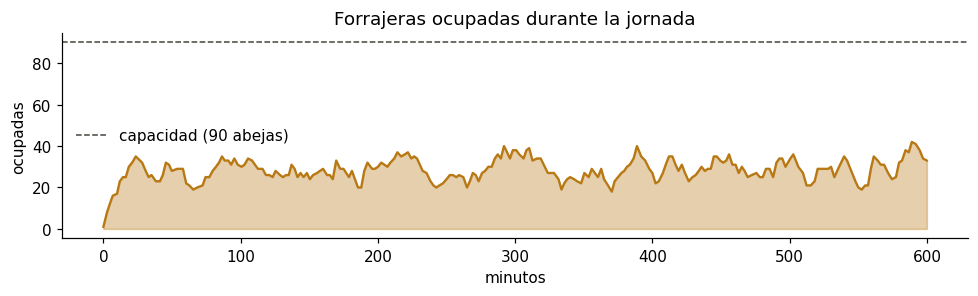

ocupación media : 28.4 de 90 forrajeras (32% de la capacidad)
ocupación máxima: 42 de 90


In [6]:
col = Colony.desde_config(cfg)
reloj, ocupadas = [], []
for t in salidas:
    abeja = col.buscar_libre(t)
    if abeja is not None:
        abeja.ocupar_hasta(t + DUR_RELLENO)
    if not reloj or t - reloj[-1] > 2.0:
        reloj.append(t); ocupadas.append(col.ocupadas(t))

fig, ax = plt.subplots(figsize=(9, 2.8))
ax.fill_between(reloj, ocupadas, color=AMBAR, alpha=.35)
ax.plot(reloj, ocupadas, color=AMBAR, lw=1.5)
ax.axhline(len(col), color=TINTA, ls='--', lw=1, label=f'capacidad ({len(col)} abejas)')
ax.set_title('Forrajeras ocupadas durante la jornada')
ax.set_xlabel('minutos'); ax.set_ylabel('ocupadas'); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f'ocupación media : {st.mean(ocupadas):.1f} de {len(col)} forrajeras '
      f'({100*st.mean(ocupadas)/len(col):.0f}% de la capacidad)')
print(f'ocupación máxima: {max(ocupadas)} de {len(col)}')

**Verificado.** La contabilidad cierra: toda salida generada queda atendida o
registrada como perdida, sin fugas. Con la configuración BASE de 90 forrajeras la
colonia atiende la totalidad de sus salidas y la ocupación se mantiene por debajo
de la capacidad.

El barrido muestra además que la pérdida de salidas es un **comportamiento
emergente** y no una regla programada: surge del choque entre la intensidad del
proceso de salidas y la capacidad de la colonia. Ese resultado es el que sustenta
la calibración de `active_bees` en 90 para la condición de referencia.

---

## 3. La disponibilidad floral y sus tres parámetros

El nivel de disponibilidad `A_f` no es un valor que se almacene: es un estado del
entorno que fija simultáneamente la media de flores visitadas, la escala del
tiempo de búsqueda y la escala del néctar por flor.

La escala de búsqueda varía en dirección contraria a las otras dos, porque en un
parche rico los recursos están concentrados y localizarlos cuesta menos tiempo.
Esa inversión es la que hace que la escasez tenga un costo temporal y no
únicamente un costo de rendimiento.

In [7]:
env = Environment.desde_config(cfg)
print(f"{'nivel':>7} {'mu_flowers':>12} {'search_scale':>14} {'nectar_scale':>14}")
for niv in ('baja', 'media', 'alta'):
    p = env.parametros(niv)
    print(f"{niv:>7} {p['mu_flowers']:12.1f} {p['search_scale']:14.2f} {p['nectar_scale']:14.3f}")

  nivel   mu_flowers   search_scale   nectar_scale
   baja          4.0           2.50          0.020
  media          8.0           1.20          0.033
   alta         14.0           0.70          0.045


In [8]:
r = crear_fuente('lcg', 77)
muestra = [env.sortear_nivel(r) for _ in range(20000)]
print(f"frecuencias del sorteo categórico sobre {len(muestra):,} viajes\n")
print(f"{'nivel':>7} {'observada':>11} {'configurada':>13}")
desvio = 0.0
for i, niv in enumerate(('baja', 'media', 'alta')):
    obs = muestra.count(niv) / len(muestra)
    desvio = max(desvio, abs(obs - env.probabilidades[i]))
    print(f'{niv:>7} {obs:11.4f} {env.probabilidades[i]:13.2f}')
comprobar('Desvío máximo del sorteo categórico', desvio, 0.0, 0.01)

frecuencias del sorteo categórico sobre 20,000 viajes

  nivel   observada   configurada
   baja      0.3054          0.30
  media      0.4949          0.50
   alta      0.1998          0.20


True

In [9]:
# En los escenarios que fijan el nivel, la disponibilidad es un factor
# experimental y no una variable aleatoria: no debe consumirse ningun uniforme.
cfg_bajo = cargar('../config/flowers_low.yaml')
env_bajo = Environment.desde_config(cfg_bajo)
r2 = crear_fuente('lcg', 1); antes = r2.consumidos
nivel_fijo = env_bajo.sortear_nivel(r2)
gasto = r2.consumidos - antes

print(f"escenario base.yaml        modo '{env.modo}'   -> nivel sorteado por viaje")
print(f"escenario flowers_low.yaml modo '{env_bajo.modo}'      -> nivel fijo '{nivel_fijo}'")
print(f"uniformes consumidos al fijar el nivel: {gasto}")
comprobar('Uniformes consumidos con nivel fijo', gasto, 0, 0)

escenario base.yaml        modo 'sample'   -> nivel sorteado por viaje
escenario flowers_low.yaml modo 'baja'      -> nivel fijo 'baja'
uniformes consumidos al fijar el nivel: 0


True

**Verificado.** Las frecuencias empíricas reproducen las probabilidades
configuradas, y un escenario que fija el nivel no consume números aleatorios.

Esta última propiedad tiene una consecuencia operativa que conviene registrar:
dos escenarios con la misma semilla recorren la secuencia de uniformes de manera
distinta según sorteen o fijen la disponibilidad. Las comparaciones entre
escenarios deben hacerse sobre distribuciones agregadas, no viaje por viaje.

---

## 4. La distancia al parche y el tiempo de vuelo

La distancia se genera por transformada inversa sobre una Weibull. Corresponde al
trayecto de la colmena al parche **solo de ida**, de modo que el tiempo de
desplazamiento del viaje completo es `2D/V`.

La forma de la distribución permanece fija en los tres escenarios de distancia;
lo que el escenario modifica es la escala.

In [10]:
r = crear_fuente('lcg', 404)
D = np.array([sortear_distancia(cfg, r) for _ in range(20000)])
k  = cfg['foraging']['distance']['shape']
lm = cfg['foraging']['distance']['scale']

media_teo   = lm * math.gamma(1 + 1/k)
mediana_teo = lm * math.log(2)**(1/k)
print(f'Weibull(forma = {k}, escala = {lm} km)\n')
print(f'  media    observada {D.mean():7.4f} km     teórica {media_teo:7.4f} km')
print(f'  mediana  observada {np.median(D):7.4f} km     teórica {mediana_teo:7.4f} km')

comprobar('Distancia media', D.mean(), media_teo, 0.03, 'km')
comprobar('Distancia mediana', np.median(D), mediana_teo, 0.03, 'km')

Weibull(forma = 2.0, escala = 1.5 km)

  media    observada  1.3232 km     teórica  1.3293 km
  mediana  observada  1.2429 km     teórica  1.2488 km


np.True_

In [11]:
print(f"{'percentil':>10} {'distancia (ida)':>17} {'vuelo ida y vuelta':>20} {'p_ret(D)':>10}")
for p in (10, 25, 50, 75, 90, 99):
    d = np.percentile(D, p)
    print(f'{p:9d}% {d:14.3f} km {tiempo_vuelo(d, cfg):17.2f} min {probabilidad_retorno(d, cfg):10.3f}')

 percentil   distancia (ida)   vuelo ida y vuelta   p_ret(D)
       10%          0.487 km              2.95 min      1.000
       25%          0.800 km              4.85 min      1.000
       50%          1.243 km              7.53 min      1.000
       75%          1.755 km             10.64 min      0.999
       90%          2.268 km             13.75 min      0.994
       99%          3.188 km             19.32 min      0.919


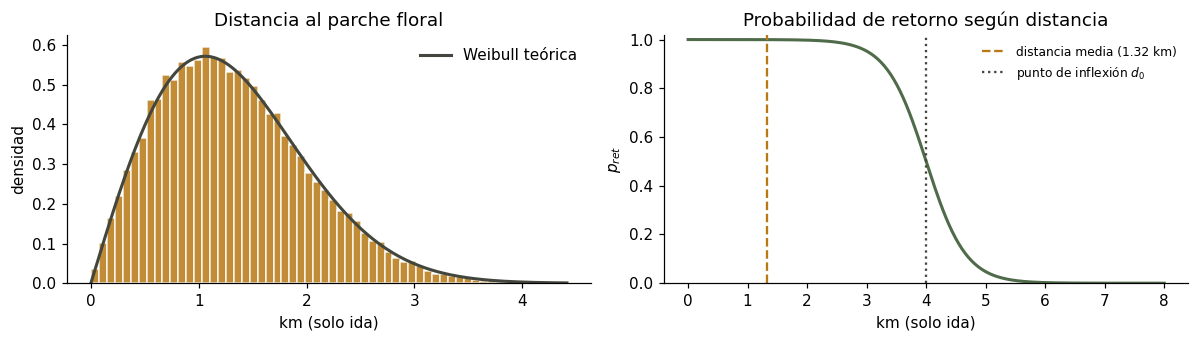

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))

ax[0].hist(D, bins=60, density=True, color=AMBAR, edgecolor='white', alpha=.85)
x = np.linspace(0, D.max(), 300)
ax[0].plot(x, (k/lm)*(x/lm)**(k-1)*np.exp(-(x/lm)**k), color=TINTA, lw=2,
           label='Weibull teórica')
ax[0].set_title('Distancia al parche floral'); ax[0].set_xlabel('km (solo ida)')
ax[0].set_ylabel('densidad'); ax[0].legend(frameon=False)

xd = np.linspace(0, 8, 300)
ax[1].plot(xd, [probabilidad_retorno(v, cfg) for v in xd], color=SALVIA, lw=2)
ax[1].axvline(D.mean(), color=AMBAR, ls='--', lw=1.5,
              label=f'distancia media ({D.mean():.2f} km)')
ax[1].axvline(cfg['return']['midpoint_km'], color=TINTA, ls=':', lw=1.5,
              label='punto de inflexión $d_0$')
ax[1].set_title('Probabilidad de retorno según distancia')
ax[1].set_xlabel('km (solo ida)'); ax[1].set_ylabel('$p_{ret}$'); ax[1].set_ylim(0, 1.02)
ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

---

## 5. Las flores visitadas

Es la variable bisagra del modelo. No es una métrica más: es el contador que
determina cuántas veces se repite todo lo que ocurre en el parche. De ella
dependen la polinización, el néctar y el tiempo de forrajeo, de modo que un error
en esta etapa afecta simultáneamente a tres métricas del informe.

La media la fija el nivel de disponibilidad verificado en la etapa 3. Bajo el
modelo Poisson la media y la varianza deben coincidir con `mu_F`.

In [13]:
N = 15000
env = Environment.desde_config(cfg)

print(f"{'nivel':>7} {'mu_F':>6} {'media obs.':>12} {'var. obs.':>11} {'var. teórica':>14}")
desvio_max = 0.0
for niv in ('baja', 'media', 'alta'):
    r = crear_fuente('lcg', 5)
    m = [flores_del_viaje(env, niv, cfg, r) for _ in range(N)]
    mt, vt = momentos_teoricos(env.mu_flores(niv), cfg)
    desvio_max = max(desvio_max, abs(st.mean(m) - mt) / mt)
    print(f'{niv:>7} {mt:6.1f} {st.mean(m):12.3f} {st.pvariance(m):11.3f} {vt:14.1f}')

comprobar('Desvío relativo máximo de la media de F', 100*desvio_max, 0.0, 1.0, '%')

  nivel   mu_F   media obs.   var. obs.   var. teórica
   baja    4.0        3.989       3.979            4.0
  media    8.0        7.988       7.897            8.0
   alta   14.0       13.982      13.841           14.0


True

In [14]:
# Variante con sobredispersión: la Binomial Negativa por composición.
# Debe conservar la media y aumentar la varianza en mu^2/r.
import copy
cfg_nb = copy.deepcopy(cfg)
cfg_nb['foraging']['flower_count_model'] = 'negbin'
cfg_nb['foraging']['overdispersion'] = 3.0

r = crear_fuente('lcg', 5)
m = [sortear_flores(8.0, cfg_nb, r) for _ in range(N)]
mt, vt = momentos_teoricos(8.0, cfg_nb)

print(f'Poisson(8)              media {8.0:6.2f}   varianza {8.0:7.2f}   (media = varianza)')
print(f'BinNeg(mu=8, r=3) obs.  media {st.mean(m):6.2f}   varianza {st.pvariance(m):7.2f}')
print(f'BinNeg(mu=8, r=3) teo.  media {mt:6.2f}   varianza {vt:7.2f}   (mu + mu²/r)')

comprobar('Media de la Binomial Negativa', st.mean(m), mt, 0.15)
comprobar('Varianza de la Binomial Negativa', st.pvariance(m), vt, 2.0)

Poisson(8)              media   8.00   varianza    8.00   (media = varianza)


BinNeg(mu=8, r=3) obs.  media   8.05   varianza   30.23
BinNeg(mu=8, r=3) teo.  media   8.00   varianza   29.33   (mu + mu²/r)


True

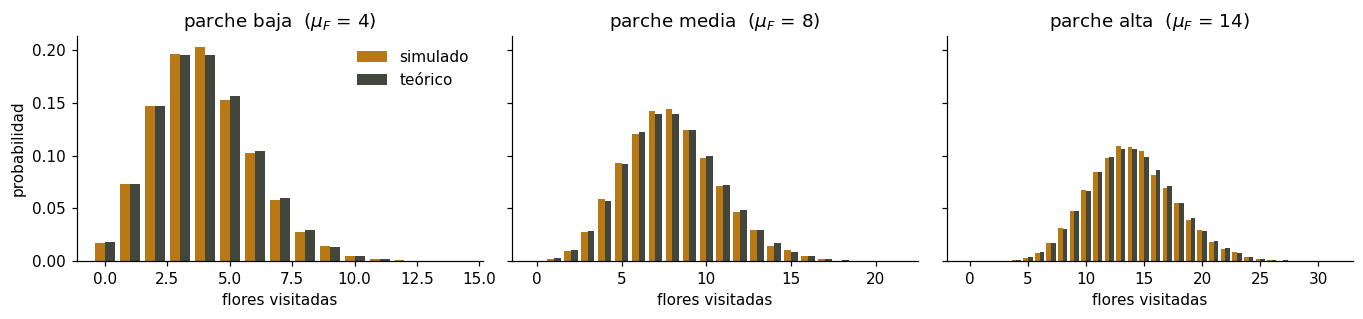

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(12.5, 3.0), sharey=True)
for a, niv in zip(ax, ('baja', 'media', 'alta')):
    r = crear_fuente('lcg', 5)
    m = np.array([flores_del_viaje(env, niv, cfg, r) for _ in range(N)])
    mu = env.mu_flores(niv)
    ks = np.arange(0, int(m.max()) + 1)
    obs = np.array([np.mean(m == k) for k in ks])
    a.bar(ks - 0.2, obs, width=.4, color=AMBAR, label='simulado')
    a.bar(ks + 0.2, stats.poisson.pmf(ks, mu), width=.4, color=TINTA, label='teórico')
    a.set_title(f'parche {niv}  ($\\mu_F$ = {mu:.0f})'); a.set_xlabel('flores visitadas')
ax[0].set_ylabel('probabilidad'); ax[0].legend(frameon=False)
plt.tight_layout(); plt.show()

**Verificado.** En los tres niveles la media empírica coincide con `mu_F` y la
varianza con ella, como exige la distribución de Poisson. La variante de
Binomial Negativa conserva la media y eleva la varianza al valor previsto por la
composición Gamma-Poisson, lo que confirma que la mezcla efectivamente produce
sobredispersión y no una Poisson disfrazada.

---

## 6. Las flores efectivamente polinizadas

Cada visita es un ensayo Bernoulli independiente. El total se construye sumando
esos ensayos y no invirtiendo una Binomial, porque el número de intentos es el
`F` de la etapa anterior y cambia en cada viaje.

Esta etapa admite una validación exacta que no requiere calibrar ningún
parámetro. Si `F ~ Poisson(μ)` y cada visita se filtra con probabilidad `p`, la
marginal de las flores polinizadas es exactamente `Poisson(μ·p)`. Por tratarse de
una Poisson, **su media y su varianza deben coincidir**, y esa igualdad es la
prueba de fuego: se cumple solo si el generador Poisson, el Bernoulli y su
encadenamiento son correctos.

In [16]:
r = crear_fuente('lcg', 6)
F = [sortear_flores(8.0, cfg, r) for _ in range(N)]
X = [polinizar(f, cfg, r) for f in F]

teo = media_marginal_teorica(8.0, cfg)
p   = cfg['pollination']['p_success']
tasas = [t for t in (tasa_observada(f, x) for f, x in zip(F, X)) if t is not None]

print(f'flores visitadas   media {st.mean(F):7.3f}')
print(f'flores polinizadas media {st.mean(X):7.3f}   teórica μ·p = {teo:.3f}')
print(f'                varianza {st.pvariance(X):7.3f}   teórica μ·p = {teo:.3f}')
print(f'tasa de polinización     {st.mean(tasas):7.4f}   configurada {p:.4f}')
print(f'\ninvariante X <= F: se cumple en los {N:,} viajes: {all(x <= f for x, f in zip(X, F))}')
print(f'tasa con cero flores visitadas: {tasa_observada(0, 0)}  (no definida, por diseño)')

comprobar('Media de flores polinizadas', st.mean(X), teo, 0.10)
comprobar('Varianza de polinizadas (adelgazamiento)', st.pvariance(X), teo, 0.20)
comprobar('Tasa de polinización observada', st.mean(tasas), p, 0.01)
comprobar('Invariante X <= F', float(all(x <= f for x, f in zip(X, F))), 1.0, 0)

flores visitadas   media   8.012
flores polinizadas media   5.213   teórica μ·p = 5.200
                varianza   5.267   teórica μ·p = 5.200
tasa de polinización      0.6507   configurada 0.6500

invariante X <= F: se cumple en los 15,000 viajes: True
tasa con cero flores visitadas: None  (no definida, por diseño)


True

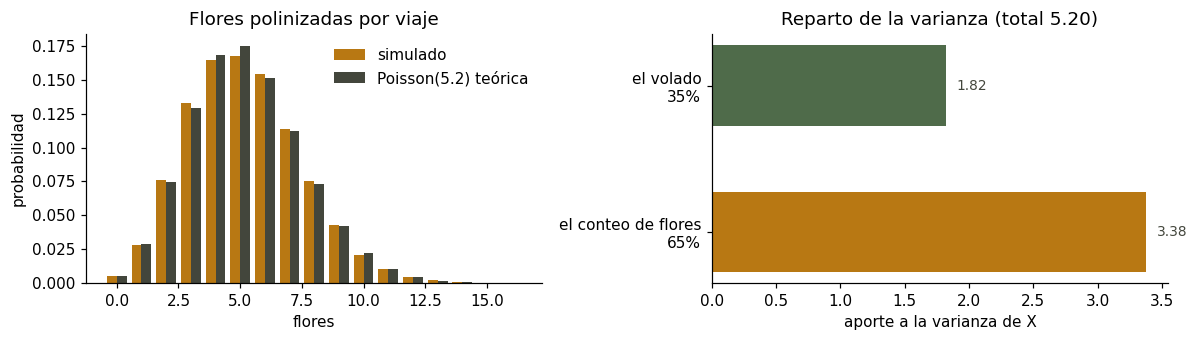

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))

Xa = np.array(X); ks = np.arange(0, Xa.max() + 1)
ax[0].bar(ks - 0.2, [np.mean(Xa == k) for k in ks], width=.4, color=AMBAR, label='simulado')
ax[0].bar(ks + 0.2, stats.poisson.pmf(ks, teo), width=.4, color=TINTA,
          label=f'Poisson({teo:.1f}) teórica')
ax[0].set_title('Flores polinizadas por viaje'); ax[0].set_xlabel('flores')
ax[0].set_ylabel('probabilidad'); ax[0].legend(frameon=False)

# de donde viene la variabilidad de X
del_volado  = 8.0 * p * (1 - p)
de_flores   = p * p * 8.0
ax[1].barh([1, 0], [del_volado, de_flores], color=[SALVIA, AMBAR], height=.55)
ax[1].set_yticks([1, 0])
ax[1].set_yticklabels([f'el volado\n{100*(1-p):.0f}%', f'el conteo de flores\n{100*p:.0f}%'])
ax[1].set_xlabel('aporte a la varianza de X')
ax[1].set_title(f'Reparto de la varianza (total {teo:.2f})')
for y, v in zip([1, 0], [del_volado, de_flores]):
    ax[1].text(v + .08, y, f'{v:.2f}', va='center', fontsize=9, color=TINTA)
plt.tight_layout(); plt.show()

**Verificado.** La distribución empírica de flores polinizadas coincide con la
`Poisson(μ·p)` teórica, su media y su varianza son iguales entre sí y al valor
previsto, y la tasa observada converge a la probabilidad configurada. El
invariante estructural `X <= F` se cumple en la totalidad de los viajes.

El panel derecho descompone la variabilidad de las flores polinizadas en sus dos
causas. La fracción aportada por el conteo de flores es exactamente `p` y la
aportada por el ensayo Bernoulli es exactamente `1-p`, de modo que con
`p = 0.65` el 65% de la incertidumbre proviene de cuántas flores encontró la
abeja y solo el 35% de cuáles cuajaron. Este resultado justifica el tratamiento
de `F` como variable crítica del modelo.

**Restricción de validez.** La propiedad de adelgazamiento exige un único nivel
de disponibilidad floral. En el escenario BASE, donde `A_f` se sortea por viaje,
la marginal agregada es una mezcla de tres distribuciones de Poisson, que es
sobredispersa y no es Poisson. Esta verificación debe ejecutarse por nivel.

**Verificado.** La muestra reproduce la media y la mediana teóricas de la
Weibull y su histograma coincide con la densidad analítica.

La curva de la derecha corresponde al modelo de retorno dependiente de la
distancia. A la distancia media del escenario la probabilidad de retorno supera
0.96, y solo el percentil 99 de los viajes se aproxima al punto de inflexión.
Cabe reiterar que esta función logística es una construcción del modelo: sus dos
parámetros son supuestos declarados y no provienen de calibración biológica.

---

## 7. Las etapas encadenadas

Los primeros viajes de la jornada, producidos por el motor tal como está
construido.

In [18]:
rng = crear_fuente(cfg['simulation']['rng_source'], cfg['simulation']['seed'])
salidas = generar_salidas_desde_config(cfg, rng)
col = Colony.desde_config(cfg); env = Environment.desde_config(cfg)

print(f"{'#':>3} {'t_salida':>10} {'abeja':>6} {'A_f':>7} {'D (km)':>8} "
      f"{'vuelo':>10} {'F':>4} {'X':>4} {'tasa':>7} {'p_ret':>8}")
print('-'*74)
hechos = 0
for t in salidas:
    abeja = col.buscar_libre(t)
    if abeja is None:
        continue
    nivel = env.sortear_nivel(rng)
    d  = sortear_distancia(cfg, rng)
    tv = tiempo_vuelo(d, cfg)
    f  = flores_del_viaje(env, nivel, cfg, rng)
    x  = polinizar(f, cfg, rng)
    abeja.ocupar_hasta(t + tv + DUR_RELLENO)
    hechos += 1
    if hechos <= 10:
        tasa = tasa_observada(f, x)
        tasa_txt = f'{tasa:.2f}' if tasa is not None else '   -'
        print(f'{hechos:3d} {t:10.3f} {abeja.bee_id:6d} {nivel:>7} {d:8.3f} '
              f'{tv:7.2f} min {f:4d} {x:4d} {tasa_txt:>7} {probabilidad_retorno(d, cfg):8.3f}')
    else:
        break
print(f'\nuniformes consumidos hasta este punto: {rng.consumidos:,}')

  #   t_salida  abeja     A_f   D (km)      vuelo    F    X    tasa    p_ret
--------------------------------------------------------------------------
  1      0.011      0   media    1.128    6.84 min   10    4    0.40    1.000
  2      0.033      1    alta    0.831    5.04 min   16    9    0.56    1.000
  3      0.053      2    baja    1.412    8.56 min    3    1    0.33    1.000
  4      0.597      3   media    3.037   18.41 min    5    5    1.00    0.947
  5      1.114      4    baja    0.619    3.75 min    3    2    0.67    1.000
  6      1.445      5    baja    0.208    1.26 min    5    2    0.40    1.000
  7      1.935      6    alta    1.393    8.44 min   15    8    0.53    1.000
  8      2.661      7   media    1.411    8.55 min    2    1    0.50    1.000
  9      2.751      8   media    1.213    7.35 min    5    2    0.40    1.000
 10      4.547      9   media    0.684    4.14 min   10    8    0.80    1.000

uniformes consumidos hasta este punto: 1,338


---

## Resumen de verificación

In [19]:
print(f"{'Comprobación':<42} {'Observado':>12} {'Esperado':>12}  {'Veredicto'}")
print('='*84)
for concepto, obs, esp, uni, ok in comprobaciones:
    u = f' {uni}' if uni else ''
    print(f'{concepto:<42} {obs:12.4f}{u:<4} {esp:8.4f}{u:<4}  {"conforme" if ok else "REVISAR"}')
print('='*84)
fallos = [c for c in comprobaciones if not c[4]]
print(f'{len(comprobaciones)} comprobaciones, {len(fallos)} fuera de tolerancia')

Comprobación                                  Observado     Esperado  Veredicto
Salidas generadas (Método A)                  1227.0000     1200.0000      conforme
Espera media entre salidas                       0.4890 min   0.5000 min  conforme
Métodos A y B, diferencia de medias              3.0000       0.0000      conforme
Salidas perdidas en BASE (90 abejas)             0.0000 %     0.0000 %    conforme
Conservación: atendidas + perdidas = generadas    1227.0000     1227.0000      conforme
Desvío máximo del sorteo categórico              0.0054       0.0000      conforme
Uniformes consumidos con nivel fijo              0.0000       0.0000      conforme
Distancia media                                  1.3232 km    1.3293 km   conforme
Distancia mediana                                1.2429 km    1.2488 km   conforme
Desvío relativo máximo de la media de F          0.2633 %     0.0000 %    conforme
Media de la Binomial Negativa                    8.0480       8.0000      conforme
V

### Conclusión

Las seis etapas verificadas producen valores consistentes con sus distribuciones
teóricas y respetan las propiedades estructurales del modelo: la contabilidad de
salidas cierra sin fugas, un escenario con disponibilidad fija no consume números
aleatorios, ninguna salida se genera fuera del horizonte de la jornada, y las
flores polinizadas nunca superan a las visitadas.

La equivalencia empírica entre los Métodos A y B confirma que ambas
representaciones del mismo proceso de salidas; su equivalencia práctica debe
comprobarse con un margen predefinido, no solo con un p-valor, lo que
habilita la comparación de costo computacional prevista en la metodología.

La verificación por adelgazamiento merece mención aparte: al comprobar que la
marginal de flores polinizadas es exactamente `Poisson(μ·p)`, valida de forma
simultánea el generador de conteo, el de ensayos Bernoulli y el encadenamiento
entre ambos, contra un valor teórico que no depende de ningún parámetro
calibrado.

---

*Documento generado por ejecución directa del código. Especificación del modelo
en `docs/model.md`; decisiones de diseño y sus alternativas descartadas en
`docs/decisions.md`; estado de avance en `docs/plan_implementacion.md`.*